In [35]:
import os

import numpy as np
import pandas as pd
from collections import Counter

import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt

# Resto degli imports...
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, label_binarize
from sklearn.metrics import (
    classification_report, 
    f1_score, 
    confusion_matrix,
    roc_curve, 
    auc,
    precision_recall_fscore_support
)

import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [36]:
df_train = pd.read_csv('../train_set/train_cleaned_outliers.csv')
df_test = pd.read_csv('../test_set/test_no_title.csv')

# drop column originalTitle
df_train = df_train.drop('originalTitle', axis=1)

In [37]:
X = df_train.drop(columns=['titleType'])
y = df_train['titleType']


In [39]:
X_test = df_test.drop(columns=['titleType', 'genreShort'])
y_test = df_test['titleType']


In [5]:
from sklearn.model_selection import train_test_split

# Suddivisione con stratificazione
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,  # 20% per la validazione
    stratify=y,     # Mantiene la distribuzione delle classi
    random_state=42 # Per riproducibilità
)
# print unique values in y_train, y_val, y_test
print("Unique values in y_train:", np.unique(y_train))
print("Unique values in y_val:", np.unique(y_val))
print("Unique values in y_test:", np.unique(y_test))


Unique values in y_train: [0 1 2 3 4]
Unique values in y_val: [0 1 2 3 4]
Unique values in y_test: [0 1 2 3 4]


In [42]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Trial 10 Complete [00h 02m 17s]
val_sparse_categorical_accuracy: 0.9055662751197815

Best val_sparse_categorical_accuracy So Far: 0.9112773537635803
Total elapsed time: 00h 26m 05s

🎯 MIGLIORI PARAMETRI TROVATI:
  units_1: 288
  dropout_1: 0.2
  second_layer: False
  third_layer: True
  learning_rate: 0.0005
  units_2: 128
  dropout_2: 0.4
  units_3: 64
  dropout_3: 0.2

🚀 TRAINING MODELLO FINALE...
Epoch 1/50
2331/2331 [==============================] - 3s 1ms/step - loss: 0.5803 - sparse_categorical_accuracy: 0.7943 - val_loss: 0.3826 - val_sparse_categorical_accuracy: 0.8654
Epoch 2/50
2331/2331 [==============================] - 2s 997us/step - loss: 0.3941 - sparse_categorical_accuracy: 0.8606 - val_loss: 0.3483 - val_sparse_categorical_accuracy: 0.8752
Epoch 3/50
2331/2331 [==============================] - 2s 960us/step - loss: 0.3620 - sparse_categorical_accuracy: 0.8732 - val_loss: 0.3305 - val_sparse_categorical_accuracy: 0.8805
Epoch 4/50
2331/2331 [=========================

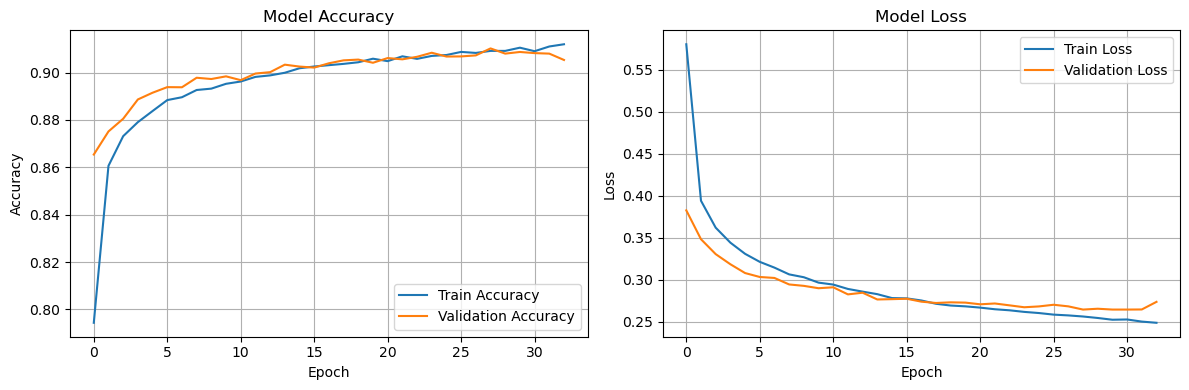


📊 PERFORMANCE FINALI:
• Train Accuracy: 0.9207
• Validation Accuracy: 0.9102
• Test Accuracy: 0.9003
• Test F1-macro: 0.8203
• Test F1-weighted: 0.8979
• Overfitting: 0.0104

🔍 ARCHITETTURA FINALE:
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 288)               12384     
                                                                 
 dropout_1 (Dropout)         (None, 288)               0         
                                                                 
 dense_3 (Dense)             (None, 64)                18496     
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_4 (Dense)             (None, 6)                 390       
                                                     

In [ ]:
def build_simple_model(hp):
    model = keras.Sequential()
    
    # Primo layer
    model.add(keras.layers.Dense(
        units=hp.Int('units_1', min_value=128, max_value=512, step=32),  # Aumenta il range
        activation='relu',
        input_shape=(X_train.shape[1],)
    ))
    model.add(keras.layers.Dropout(rate=hp.Float('dropout_1', 0.2, 0.5, step=0.1)))
    
    # Secondo layer opzionale
    if hp.Boolean('second_layer'):
        model.add(keras.layers.Dense(
            units=hp.Int('units_2', min_value=64, max_value=128, step=32),  # Aumenta il range
            activation='relu'
        ))
        model.add(keras.layers.Dropout(rate=hp.Float('dropout_2', 0.2, 0.4, step=0.1)))
    
    # Terzo layer opzionale per relazioni complesse
    if hp.Boolean('third_layer'):
        model.add(keras.layers.Dense(
            units=hp.Int('units_3', min_value=32, max_value=64, step=16),  # Nuovo layer
            activation='relu'
        ))
        model.add(keras.layers.Dropout(rate=hp.Float('dropout_3', 0.2, 0.4, step=0.1)))
    


    # Output layer
    model.add(keras.layers.Dense(6, activation='softmax'))
    
    # Optimizer semplice
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', [5e-4])  # Aggiungi valori più alti
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['sparse_categorical_accuracy']
    )
    return model

# TUNER SEMPLICE
tuner = kt.RandomSearch(
    build_simple_model,
    objective='val_accuracy',
    max_trials=10,  # Ridotto per velocità
    executions_per_trial=1,
    directory='simple_tuning_reset',
    project_name='simple_reset',
    overwrite=True
)
# 🔧 CALLBACKS CORRETTI - devono usare il nome esatto della metrica
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_sparse_categorical_accuracy',  # NOME CORRETTO
        patience=20,
        restore_best_weights=True,
        mode='max'  # Massimizza accuracy
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_sparse_categorical_accuracy',  # NOME CORRETTO
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        mode='max'  # Massimizza accuracy
    )
]

# TUNER CORRETTO
tuner = kt.RandomSearch(
    build_simple_model,
    objective='val_sparse_categorical_accuracy',  # NOME CORRETTO
    max_trials=10,
    executions_per_trial=2,
    directory='simple_tuning_reset',
    project_name='simple_reset',
    overwrite=True
)

# SEARCH
tuner.search(
    X_train_scaled, y_train,
    epochs=50,
    validation_data=(X_val_scaled, y_val),
    batch_size=64,
    callbacks=callbacks,  # Callbacks corretti
    verbose=1
)

# MIGLIORI PARAMETRI
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n🎯 MIGLIORI PARAMETRI TROVATI:")
for param, value in best_hps.values.items():
    print(f"  {param}: {value}")

# 🔧 TRAINING FINALE CORRETTO
print("\n🚀 TRAINING MODELLO FINALE...")
final_model = tuner.hypermodel.build(best_hps)

history = final_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    validation_data=(X_val_scaled, y_val),
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_sparse_categorical_accuracy',  # NOME CORRETTO
            patience=5,
            restore_best_weights=True,
            mode='max'
        )
    ],
    verbose=1
)

# VISUALIZZAZIONE CORRETTA
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
# USA I NOMI CORRETTI DELLA METRICA
plt.plot(history.history['sparse_categorical_accuracy'], label='Train Accuracy')
plt.plot(history.history['val_sparse_categorical_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# EVALUATION
train_acc = final_model.evaluate(X_train_scaled, y_train, verbose=0)[1]
val_acc = final_model.evaluate(X_val_scaled, y_val, verbose=0)[1]
test_acc = final_model.evaluate(X_test_scaled, y_test, verbose=0)[1]

y_pred = final_model.predict(X_test_scaled, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

f1_macro = f1_score(y_test, y_pred_classes, average='macro')
f1_weighted = f1_score(y_test, y_pred_classes, average='weighted')

print(f"\n📊 PERFORMANCE FINALI:")
print(f"• Train Accuracy: {train_acc:.4f}")
print(f"• Validation Accuracy: {val_acc:.4f}")
print(f"• Test Accuracy: {test_acc:.4f}")
print(f"• Test F1-macro: {f1_macro:.4f}")
print(f"• Test F1-weighted: {f1_weighted:.4f}")
print(f"• Overfitting: {train_acc - val_acc:.4f}")

print(f"\n🔍 ARCHITETTURA FINALE:")
final_model.summary()

In [ ]:
# SALVA IL MODELLO (non la history!)
final_model.save('./models/NN_titleType/NN_titleType_classifier.h5')


# save best hyperparameters
with open('./models/NN_titleType/NN_titleType_best_params.pkl', 'wb') as f:
    pickle.dump(best_hps.values, f)

# save history
with open('./models/NN_titleType/NN_titleType_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

# save scaler
with open('./models/NN_titleType/NN_titleType_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [52]:
# load the best model
final_model = keras.models.load_model('./models/NN_titleType/NN_titleType_classifier.h5')
# load the best hyperparameters
with open('./models/NN_titleType/NN_titleType_best_params.pkl', 'rb') as f:
    best_hps = pickle.load(f)
# load the scaler
with open('./models/NN_titleType/NN_titleType_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

1135/1135 [==============================] - 1s 534us/step


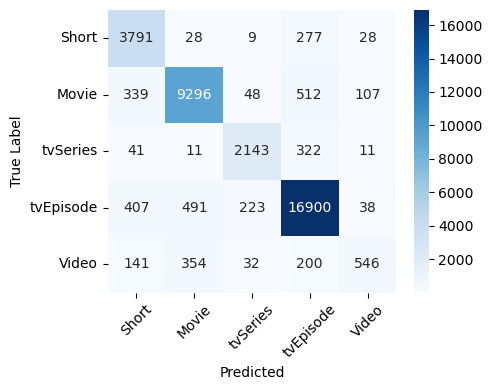

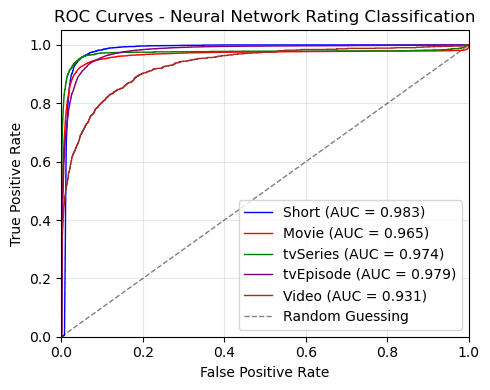


📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       Short       0.80      0.92      0.86      4133
       Movie       0.91      0.90      0.91     10302
    tvSeries       0.87      0.85      0.86      2528
   tvEpisode       0.93      0.94      0.93     18059
       Video       0.75      0.43      0.55      1273

    accuracy                           0.90     36295
   macro avg       0.85      0.81      0.82     36295
weighted avg       0.90      0.90      0.90     36295


🎯 RATING METRICS:
Mean Absolute Error (Rating): 0.207

📊 ERROR DISTRIBUTION:
  Error 0: 32676 samples (90.0%)
  Error 1: 1209 samples (3.3%)
  Error 2: 1096 samples (3.0%)
  Error 3: 1145 samples (3.2%)
  Error 4: 169 samples (0.5%)


In [ ]:
# ...existing code...
label_map = {
    0: 'Short',
    1: 'Movie',
    2: 'tvSeries',
    3: 'tvEpisode',
    4: 'Video'
}

# PREDIZIONI CORRETTE per Neural Network
y_pred_proba = final_model.predict(X_test_scaled)  # Probabilità da NN
y_pred = np.argmax(y_pred_proba, axis=1)  # Classi predette (0-5)

# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))

# Crea le label per gli assi usando il mapping
class_labels = [label_map[i] for i in range(len(label_map))]

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)  # Mantieni orizzontali per leggibilità
plt.xlabel('Predicted')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# ROC CURVES
# Binarizza le etichette per multiclass ROC
y_test_bin = label_binarize(y_test, classes=sorted(np.unique(y_test)))
n_classes = y_test_bin.shape[1]

# Calcola le curve ROC e AUC per ogni classe
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])  # Usa probabilità NN
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot delle curve ROC
plt.figure(figsize=(5, 4))
colors = ['blue', 'red', 'green', 'purple', 'brown', 'orange']

for i in range(n_classes):
    plt.plot(
        fpr[i], tpr[i], 
        color=colors[i % len(colors)],
        lw=1,
        label=f'{label_map[i]} (AUC = {roc_auc[i]:.3f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guessing', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Neural Network Rating Classification')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# CLASSIFICATION REPORT
from sklearn.metrics import classification_report
print("\n📋 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=class_labels))

# METRICHE AGGIUNTIVE per rating
from sklearn.metrics import mean_absolute_error
y_test_rating = y_test + 4  # Convert to original rating (4-9)
y_pred_rating = y_pred + 4

mae = mean_absolute_error(y_test_rating, y_pred_rating)
print(f"\n🎯 RATING METRICS:")
print(f"Mean Absolute Error (Rating): {mae:.3f}")

# Distribuzione errori
errors = np.abs(y_test_rating - y_pred_rating)
print(f"\n📊 ERROR DISTRIBUTION:")
for error in sorted(np.unique(errors)):
    count = np.sum(errors == error)
    pct = count / len(errors) * 100
    print(f"  Error {error}: {count} samples ({pct:.1f}%)")